Task 2: Customer Segmentation Using Unsupervised Learning
Objective: Cluster customers based on spending habits and propose marketing strategies tailored to each segment using K-Means and PCA.

First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


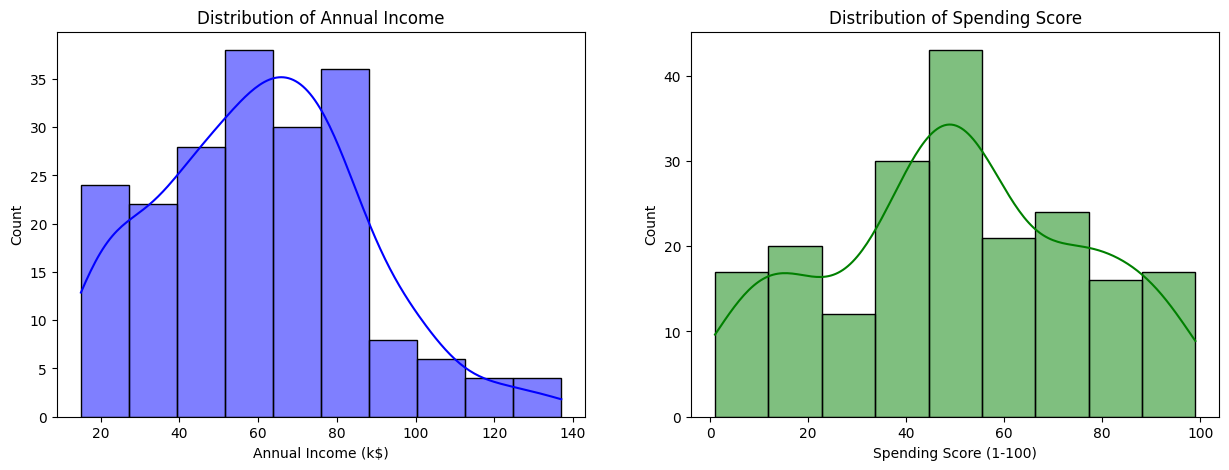

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Load the dataset
df = pd.read_csv('Mall_Customers.csv')

# 2. View basic info
print("First 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

# 3. Drop CustomerID as it has no predictive value
df = df.drop('CustomerID', axis=1)

# 4. Visualize the distributions
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['Annual Income (k$)'], kde=True, color='blue')
plt.title('Distribution of Annual Income')

plt.subplot(1, 2, 2)
sns.histplot(df['Spending Score (1-100)'], kde=True, color='green')
plt.title('Distribution of Spending Score')
plt.show()

# 5. Prepare data for clustering (using only Income and Spending Score for clear 2D clusters initially)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

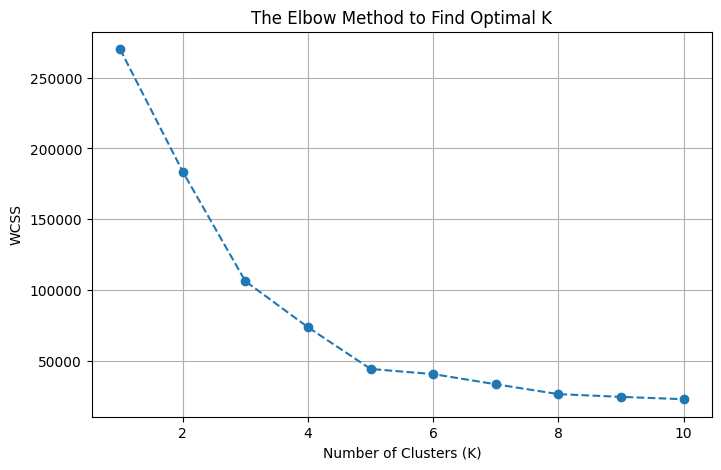

In [2]:
from sklearn.cluster import KMeans

# Calculate WCSS (Within-Cluster Sum of Square) for K values from 1 to 10
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method to Find Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

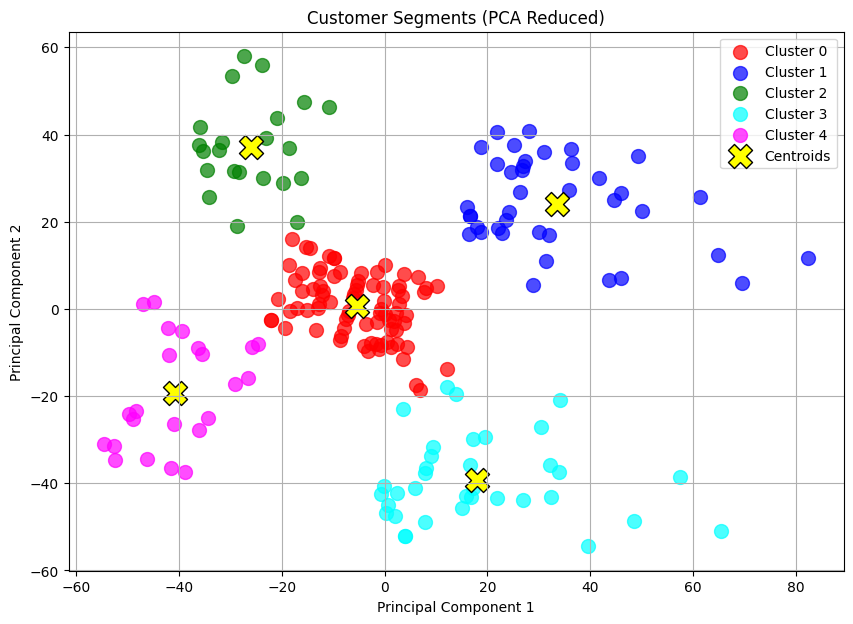

In [3]:
from sklearn.decomposition import PCA

# 1. Train the K-Means model with 5 clusters
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Add the cluster assignments back to our original dataframe for analysis
df['Cluster'] = y_kmeans

# 2. Apply PCA to reduce dimensionality for visualization
# Even though we only used 2 features here, PCA is best practice for higher dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 3. Visualize the Clusters
plt.figure(figsize=(10, 7))
colors = ['red', 'blue', 'green', 'cyan', 'magenta']
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

for i in range(5):
    plt.scatter(X_pca[y_kmeans == i, 0], X_pca[y_kmeans == i, 1], 
                s=100, c=colors[i], label=labels[i], alpha=0.7)

# Plot the centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], s=300, c='yellow', marker='X', label='Centroids', edgecolors='black')

plt.title('Customer Segments (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

Business Insights & Marketing Strategies
Based on our K-Means clustering, we have identified 5 distinct customer segments:

Cluster 0 (High Income, Low Spenders): These customers have money but are careful with it.

Strategy: Target them with high-quality, durable, and premium products. Offer loyalty programs that emphasize value and exclusivity.

Cluster 1 (Average Income, Average Spenders): This is the largest segment and the baseline of the mall's revenue.

Strategy: Standard promotional campaigns, seasonal sales, and bundle offers work best here to gently push their spending score up.

Cluster 2 (High Income, High Spenders): These are the VIPs.

Strategy: Target with luxury items, personalized services, and early access to new collections. Retention is critical here.

Cluster 3 (Low Income, Low Spenders): These customers are highly budget-conscious.

Strategy: Focus on discount events, clearance sales, and budget-friendly essentials.

Cluster 4 (Low Income, High Spenders): These customers love to shop despite lower incomes, likely driven by trends or impulse buying.

Strategy: Promote trendy, accessible, low-ticket items. Leverage flash sales and social media marketing to capture impulse purchases.